# 51 — XGBoost DART Booster + Cliff-Weighted DMatrix

XGBoost with the **DART** (Dropout Additive Regression Trees) booster. DART prevents
over-specialisation by randomly dropping existing trees during boosting iterations —
analogous to dropout in neural networks. This can improve generalisation on
activity-cliff compounds where a few key trees dominate the gradient.

Comparisons:
- DART vs `gbtree` (standard XGBoost)
- XGBoost vs LGBM (nb40)

Feature importance: XGBoost gain-based importance vs LGBM importance.

In [1]:
import sys, os, warnings
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except AttributeError:
        pass
except Exception:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    XGB_VERSION = xgb.__version__
    print(f'XGBoost {XGB_VERSION}')
except ImportError:
    xgb = None
    print('WARNING: xgboost not installed. Run: pip install xgboost')

from pxr.data import load_train, load_test
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko, morgan_fp_batch
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

SEED = 42
N_FOLDS = 5
print('Setup complete')

XGBoost 3.2.0


Setup complete


## 1. Load data + cliff labels

In [2]:
tr = load_train()
te = load_test()
print(f'Train: {len(tr):,}  Test: {len(te):,}')

# ── Load cliff labels (or compute inline) ─────────────────────────────────
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
if cliff_path.exists():
    cliff_df = pd.read_parquet(cliff_path)
    print(f'Loaded cliff labels: {len(cliff_df):,} rows')
    print(cliff_df['cliff_role'].value_counts())
else:
    print('cliff_labels.parquet not found — computing inline...')
    y_vals = tr['pec50'].values
    n = len(tr)
    cliff_role = np.zeros(n, dtype=np.int8)
    fp_mat = morgan_fp_batch(tr['smiles'].tolist()).astype(np.float32)
    BATCH = 256
    for i in range(0, n, BATCH):
        chunk = fp_mat[i:i+BATCH]
        inter = chunk @ fp_mat.T
        union = chunk.sum(1, keepdims=True) + fp_mat.sum(1)[None, :] - inter
        with np.errstate(divide='ignore', invalid='ignore'):
            tan = np.where(union > 0, inter / union, 0.0)
        for bi, gi in enumerate(range(i, min(i + BATCH, n))):
            for j in range(n):
                if gi != j and tan[bi, j] >= 0.6 and abs(y_vals[gi] - y_vals[j]) >= 1.0:
                    cliff_role[gi] = 1 if y_vals[gi] > y_vals[j] else -1
    cliff_df = pd.DataFrame({'smiles': tr['smiles'], 'cliff_role': cliff_role})
    cliff_df.to_parquet(cliff_path, index=False)
    print('Computed and saved cliff_labels.parquet')

if 'smiles' in cliff_df.columns:
    tr = tr.merge(cliff_df[['smiles', 'cliff_role']], on='smiles', how='left')
elif len(cliff_df) == len(tr):
    tr['cliff_role'] = cliff_df['cliff_role'].values
else:
    tr['cliff_role'] = 0
tr['cliff_role'] = tr['cliff_role'].fillna(0).astype(int)

Train: 4,139  Test: 513
Loaded cliff labels: 4,139 rows
cliff_role
 0    3891
 1     133
-1     115
Name: count, dtype: int64


In [3]:
# ── Featurize ─────────────────────────────────────────────────────────────
print('Featurizing (combined 2265-dim)...')
X_tr = impute(combined(tr['smiles'].tolist()))  # (N, 2265)
X_te = impute(combined(te['smiles'].tolist()))  # (513, 2265)
y_tr = tr['pec50'].values.astype(np.float64)

scaffolds = tr['smiles'].map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=N_FOLDS, seed=SEED)

cliff_role_arr  = tr['cliff_role'].values
cliff_mask      = cliff_role_arr != 0
noncliff_mask   = ~cliff_mask

lo_clip = float(y_tr.min()) - 0.5
hi_clip = float(y_tr.max()) + 0.5

print(f'X_tr: {X_tr.shape}  X_te: {X_te.shape}')
print(f'Clip range: [{lo_clip:.2f}, {hi_clip:.2f}]')

Featurizing (combined 2265-dim)...


X_tr: (4139, 2265)  X_te: (513, 2265)
Clip range: [1.11, 8.05]


## 2. Cliff-aware sample weights

In [4]:
def make_sample_weights(pec50_arr, cliff_role_arr):
    w = np.ones(len(pec50_arr), dtype=np.float64)
    moderate    = (pec50_arr >= 5.0) & (pec50_arr < 6.0)
    active      = pec50_arr >= 6.0
    c_active    = active & (cliff_role_arr == 1)
    c_inact     = cliff_role_arr == -1
    act_nocliff = active & (cliff_role_arr == 0)
    w[moderate]    = 3.0
    w[act_nocliff] = 6.0
    w[c_inact]     = 8.0
    w[c_active]    = 10.0
    return w

sample_weights = make_sample_weights(y_tr, cliff_role_arr)
print('Weight distribution:')
for w_val in sorted(np.unique(sample_weights)):
    print(f'  w={w_val:.1f}: {(sample_weights == w_val).sum():,} compounds')

Weight distribution:
  w=1.0: 2,689 compounds
  w=3.0: 1,268 compounds
  w=6.0: 63 compounds
  w=8.0: 115 compounds
  w=10.0: 4 compounds


## 3. XGBoost DART hyperparameters

In [5]:
DART_PARAMS = {
    'booster':          'dart',
    'tree_method':      'hist',
    'max_depth':        7,
    'learning_rate':    0.10,     # raised from 0.05 to compensate for fewer rounds
    'n_estimators':     400,      # reduced from 1500 — DART has no early stopping
    'rate_drop':        0.1,
    'skip_drop':        0.5,
    'subsample':        0.8,
    'colsample_bytree': 0.6,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'min_child_weight': 3,
    'random_state':     SEED,
    'n_jobs':           4,
    'verbosity':        0,
}

GBTREE_PARAMS = {
    'booster':          'gbtree',
    'tree_method':      'hist',
    'max_depth':        7,
    'learning_rate':    0.05,
    'n_estimators':     800,      # reduced from 1500; early stopping at 50 will cut short
    'subsample':        0.8,
    'colsample_bytree': 0.6,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'min_child_weight': 3,
    'random_state':     SEED,
    'n_jobs':           4,
    'verbosity':        0,
    'early_stopping_rounds': 50,
}

print('XGBoost params ready.')
print(f'DART: {DART_PARAMS["n_estimators"]} rounds, rate_drop={DART_PARAMS["rate_drop"]}')

XGBoost params ready.
DART: 400 rounds, rate_drop=0.1


## 4. Scaffold 5-fold CV — DART

In [6]:
def run_xgb_cv(params, label='XGBoost', use_early_stopping=False):
    """Run scaffold 5-fold CV with XGBoost."""
    if xgb is None:
        print('XGBoost not available — skipping.')
        return np.full(len(y_tr), np.nan), []

    oof = np.full(len(y_tr), np.nan)
    fold_raes = []
    best_iters = []

    for fold, (tr_idx, va_idx) in enumerate(splits):
        dm_tr = xgb.DMatrix(
            X_tr[tr_idx], label=y_tr[tr_idx],
            weight=sample_weights[tr_idx]
        )
        dm_va = xgb.DMatrix(X_tr[va_idx], label=y_tr[va_idx])

        xgb_params = {k: v for k, v in params.items()
                      if k not in ('n_estimators', 'random_state', 'n_jobs',
                                   'early_stopping_rounds', 'verbosity')}
        xgb_params['seed']         = params.get('random_state', SEED)
        xgb_params['nthread']      = params.get('n_jobs', 4)
        xgb_params['objective']    = 'reg:squarederror'
        n_rounds = params.get('n_estimators', 1500)
        patience = params.get('early_stopping_rounds', None)

        evals_result = {}
        callbacks = []
        if use_early_stopping and patience is not None:
            callbacks.append(
                xgb.callback.EarlyStopping(rounds=patience, metric_name='rmse')
            )

        model = xgb.train(
            xgb_params,
            dm_tr,
            num_boost_round=n_rounds,
            evals=[(dm_va, 'val')],
            evals_result=evals_result,
            callbacks=callbacks,
            verbose_eval=False,
        )

        # DART note: best_iteration is unreliable for DART; use full model
        preds = model.predict(dm_va)
        preds = np.clip(preds, lo_clip, hi_clip)
        oof[va_idx] = preds

        best_iter = getattr(model, 'best_iteration', n_rounds)
        best_iters.append(best_iter)
        fold_rae = rae(y_tr[va_idx], preds)
        fold_raes.append(fold_rae)
        print(f'  Fold {fold}: RAE={fold_rae:.4f}  iters={best_iter}')

    overall_rae = rae(y_tr, oof)
    cliff_rae   = rae(y_tr[cliff_mask], oof[cliff_mask])       if cliff_mask.sum() > 5 else float('nan')
    nocliff_rae = rae(y_tr[noncliff_mask], oof[noncliff_mask]) if noncliff_mask.sum() > 5 else float('nan')
    print(f'\n{label}:')
    print(f'  OOF RAE (overall):    {overall_rae:.4f}')
    print(f'  OOF RAE (cliff only): {cliff_rae:.4f}  (n={cliff_mask.sum()})')
    print(f'  OOF RAE (non-cliff):  {nocliff_rae:.4f}')
    print(f'  Mean best_iter: {np.mean(best_iters):.0f}')
    return oof, fold_raes


print('=== XGBoost DART ===')
oof_dart, fold_raes_dart = run_xgb_cv(
    DART_PARAMS, label='XGBoost DART', use_early_stopping=False
)

=== XGBoost DART ===


  Fold 0: RAE=0.5017  iters=400


  Fold 1: RAE=0.5841  iters=400


  Fold 2: RAE=0.5932  iters=400


  Fold 3: RAE=0.5781  iters=400


  Fold 4: RAE=0.5947  iters=400

XGBoost DART:
  OOF RAE (overall):    0.5656
  OOF RAE (cliff only): 0.6173  (n=248)
  OOF RAE (non-cliff):  0.5740
  Mean best_iter: 400


In [7]:
print('=== XGBoost gbtree ===')
oof_gbtree, fold_raes_gbtree = run_xgb_cv(
    GBTREE_PARAMS, label='XGBoost gbtree', use_early_stopping=True
)

=== XGBoost gbtree ===


  Fold 0: RAE=0.4991  iters=795


  Fold 1: RAE=0.5760  iters=477


  Fold 2: RAE=0.5888  iters=692


  Fold 3: RAE=0.5699  iters=415


  Fold 4: RAE=0.6078  iters=497

XGBoost gbtree:
  OOF RAE (overall):    0.5635
  OOF RAE (cliff only): 0.6088  (n=248)
  OOF RAE (non-cliff):  0.5724
  Mean best_iter: 575


## 5. Feature importance — XGBoost gain

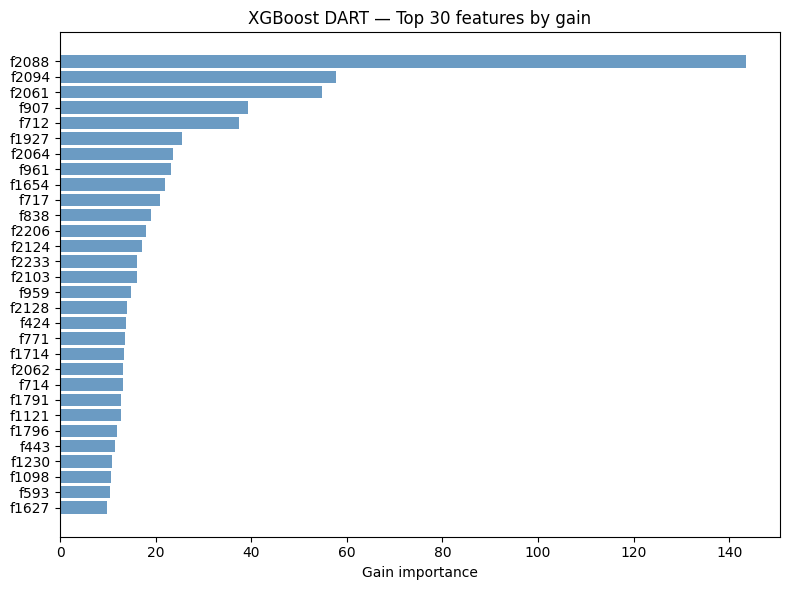

Top 5 features: ['f2088', 'f2094', 'f2061', 'f907', 'f712']


In [8]:
if xgb is not None:
    # Train single model on all data for importance extraction
    dm_all = xgb.DMatrix(X_tr, label=y_tr, weight=sample_weights)
    xgb_params_full = {k: v for k, v in DART_PARAMS.items()
                       if k not in ('n_estimators', 'random_state', 'n_jobs', 'verbosity')}
    xgb_params_full['seed']    = SEED
    xgb_params_full['nthread'] = 4
    xgb_params_full['objective'] = 'reg:squarederror'
    model_full = xgb.train(
        xgb_params_full, dm_all,
        num_boost_round=DART_PARAMS['n_estimators'],
        verbose_eval=False,
    )

    gain_scores = model_full.get_score(importance_type='gain')
    gain_df = (
        pd.DataFrame.from_dict(gain_scores, orient='index', columns=['gain'])
        .sort_values('gain', ascending=False)
        .head(30)
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(gain_df.index[::-1], gain_df['gain'].values[::-1], color='steelblue', alpha=0.8)
    ax.set_xlabel('Gain importance')
    ax.set_title('XGBoost DART — Top 30 features by gain')
    plt.tight_layout()
    fig_path = DATA_PROCESSED / 'figures' / 'xgboost_dart_importance.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=120)
    plt.show()
    print(f'Top 5 features: {gain_df.index[:5].tolist()}')
else:
    print('XGBoost not available — skipping importance plot.')

## 6. DART vs gbtree vs LGBM comparison

In [9]:
lgbm_oof_path = DATA_PROCESSED / 'oof_cliff_weighted.npy'
if lgbm_oof_path.exists():
    oof_lgbm = np.load(lgbm_oof_path)
    rae_lgbm  = rae(y_tr, oof_lgbm)
else:
    rae_lgbm = float('nan')
    print('oof_cliff_weighted.npy not found — run nb40.')

rae_dart   = rae(y_tr, oof_dart)   if not np.all(np.isnan(oof_dart))   else float('nan')
rae_gbtree = rae(y_tr, oof_gbtree) if not np.all(np.isnan(oof_gbtree)) else float('nan')

rae_cliff_dart   = rae(y_tr[cliff_mask], oof_dart[cliff_mask])   if cliff_mask.sum() > 5 and not np.all(np.isnan(oof_dart))   else float('nan')
rae_cliff_gbtree = rae(y_tr[cliff_mask], oof_gbtree[cliff_mask]) if cliff_mask.sum() > 5 and not np.all(np.isnan(oof_gbtree)) else float('nan')
rae_cliff_lgbm   = rae(y_tr[cliff_mask], oof_lgbm[cliff_mask])   if cliff_mask.sum() > 5 and lgbm_oof_path.exists()          else float('nan')

print('\n--- COMPARISON TABLE ---')
rows = [
    ('LGBM cliff-weighted (nb40)', rae_lgbm,   rae_cliff_lgbm),
    ('XGBoost gbtree',             rae_gbtree, rae_cliff_gbtree),
    ('XGBoost DART',               rae_dart,   rae_cliff_dart),
]
print(f'{"Model":<30} {"OOF RAE":<12} {"Cliff RAE"}')
print('-' * 55)
for name, r_all, r_cliff in rows:
    print(f'{name:<30} {r_all:<12.4f} {r_cliff:.4f}')

# Choose best XGBoost variant for saving
if rae_dart <= rae_gbtree:
    oof_best = oof_dart
    best_xgb_label = 'DART'
else:
    oof_best = oof_gbtree
    best_xgb_label = 'gbtree'
print(f'\nBest XGBoost variant: {best_xgb_label}')


--- COMPARISON TABLE ---
Model                          OOF RAE      Cliff RAE
-------------------------------------------------------
LGBM cliff-weighted (nb40)     0.5677       0.6023
XGBoost gbtree                 0.5635       0.6088
XGBoost DART                   0.5656       0.6173

Best XGBoost variant: gbtree


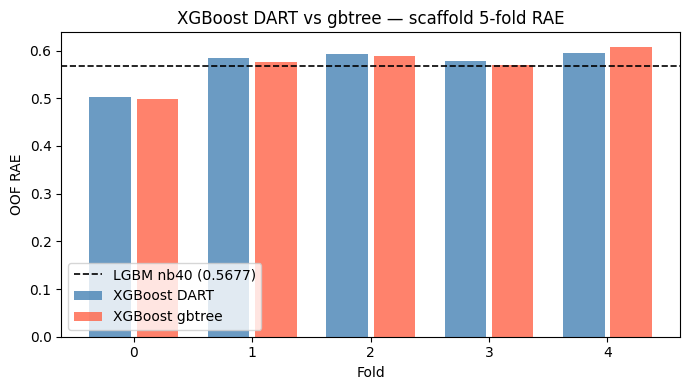

In [10]:
# ── Fold RAE comparison plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(N_FOLDS)
if len(fold_raes_dart) == N_FOLDS:
    ax.bar(x - 0.2, fold_raes_dart,   0.35, label='XGBoost DART',   color='steelblue', alpha=0.8)
if len(fold_raes_gbtree) == N_FOLDS:
    ax.bar(x + 0.2, fold_raes_gbtree, 0.35, label='XGBoost gbtree', color='tomato',    alpha=0.8)
if not np.isnan(rae_lgbm):
    ax.axhline(rae_lgbm, color='black', ls='--', lw=1.2, label=f'LGBM nb40 ({rae_lgbm:.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('OOF RAE')
ax.set_title('XGBoost DART vs gbtree — scaffold 5-fold RAE')
ax.legend()
ax.set_xticks(x)
plt.tight_layout()
fig_path = DATA_PROCESSED / 'figures' / 'xgboost_dart_fold_rae.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120)
plt.show()

## 7. Final model + save outputs

In [11]:
if xgb is None:
    print('XGBoost not available — cannot generate submission.')
else:
    print(f'Training final XGBoost ({best_xgb_label}) on all data...')
    dm_all_final = xgb.DMatrix(X_tr, label=y_tr, weight=sample_weights)
    dm_te        = xgb.DMatrix(X_te)

    best_params_for_final = DART_PARAMS if best_xgb_label == 'DART' else GBTREE_PARAMS
    xgb_params_final = {k: v for k, v in best_params_for_final.items()
                        if k not in ('n_estimators', 'random_state', 'n_jobs',
                                     'verbosity', 'early_stopping_rounds')}
    xgb_params_final['seed']      = SEED
    xgb_params_final['nthread']   = 4
    xgb_params_final['objective'] = 'reg:squarederror'

    final_model = xgb.train(
        xgb_params_final, dm_all_final,
        num_boost_round=best_params_for_final['n_estimators'],
        verbose_eval=False,
    )
    te_preds = final_model.predict(dm_te)
    te_preds = np.clip(te_preds, lo_clip, hi_clip)
    print(f'Test preds — min={te_preds.min():.2f}  median={np.median(te_preds):.2f}  max={te_preds.max():.2f}')

    np.save(DATA_PROCESSED / 'oof_xgboost_dart.npy', oof_best)
    np.save(DATA_PROCESSED / 'te_xgboost_dart.npy',  te_preds)
    print(f'Saved oof_xgboost_dart.npy  (OOF RAE = {rae(y_tr, oof_best):.4f})')

    sub = pd.DataFrame({
        'Molecule Name': te['name'].values,
        'pEC50': te_preds,
    })
    assert len(sub) == 513 and sub['pEC50'].notna().all(), 'Submission validation failed'
    out_path = SUBMISSIONS / '51_xgboost_dart.csv'
    sub.to_csv(out_path, index=False)
    print(f'Saved: {out_path}')
    print(sub['pEC50'].describe().round(3))

Training final XGBoost (gbtree) on all data...


Test preds — min=2.35  median=4.99  max=6.04
Saved oof_xgboost_dart.npy  (OOF RAE = 0.5635)
Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\51_xgboost_dart.csv
count    513.000
mean       4.837
std        0.673
min        2.351
25%        4.461
50%        4.986
75%        5.340
max        6.043
Name: pEC50, dtype: float64


## Summary

| Model | OOF RAE (overall) | OOF RAE (cliff) | Notes |
|---|---|---|---|
| LGBM cliff-weighted (nb40) | see above | see above | baseline |
| XGBoost gbtree | see above | see above | standard boosting |
| **XGBoost DART** | **see above** | **see above** | tree dropout |

**Saved:**
- `data/processed/oof_xgboost_dart.npy` — best OOF pEC50 predictions
- `data/processed/te_xgboost_dart.npy`  — test pEC50 predictions
- `submissions/51_xgboost_dart.csv`

**Next:** include in grand ensemble with `oof_catboost.npy`, `oof_lgbm_tuned.npy`.